In [1]:
# import all the neccessary modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns

In [2]:
from functools import partial
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression as LR
from sklearn.model_selection import(cross_validate, KFold, ShuffleSplit)
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.base import clone

In [3]:
# install the ISLP model
!pip install ISLP

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 6.7 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=30122e93ab8bd67aa8d0247d91e5314845e0d24d1d6877f3856a5dd35be56ec2
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [4]:
# Import the following to load the data from ISLP book
from ISLP import load_data
from ISLP.models import(ModelSpec as MS, summarize, poly)
from ISLP.models import sklearn_sm

In [5]:
# loading the main data for analysis
#f = pd.read_csv("D:\hirko\courses\ML\ALL CSV FILES - 2nd Edition\Boston.csv")
df = load_data('Boston')
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


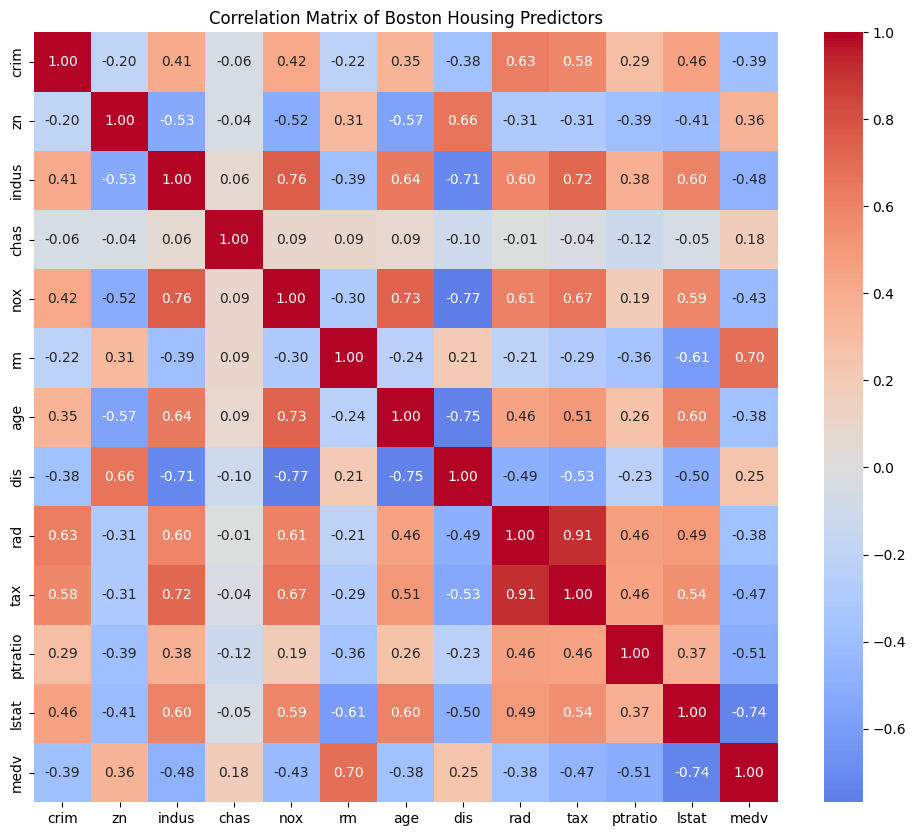

In [26]:
# To visualize the correlation of the variables in the data
corr_matrix = df.corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix of Boston Housing Predictors')

plt.savefig("Correlation_Matrix.png", dpi=150, bbox_inches='tight')


In [27]:
from google.colab import files
files.download('Correlation_matrix.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Checking and cleaning data for analyisis
df.isnull().sum()
df.dtypes
df['chas'].unique()
#df['rad'].max()
df.describe()
#df['medv'].min()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000


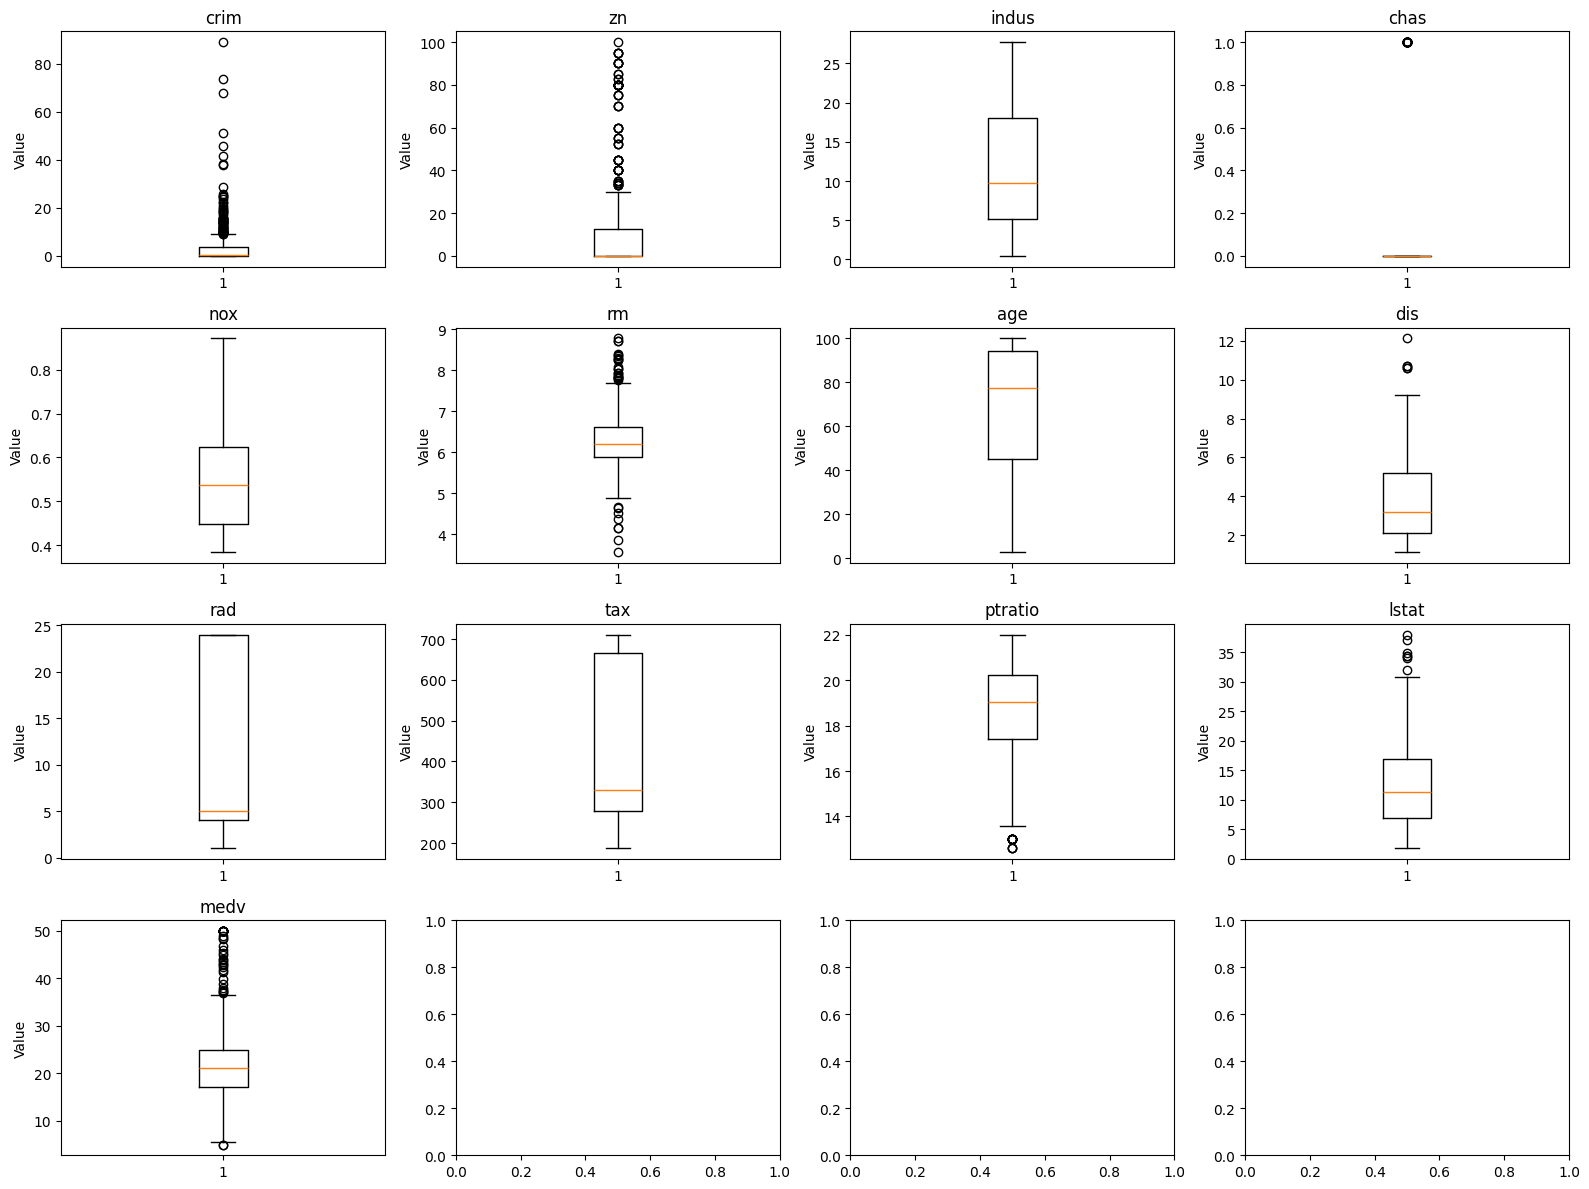

In [ ]:
# plotting the boxplot to check the outliers
fig, axes = plt.subplots(4,4, figsize=(16,12))
axes = axes.flatten()
for i, col in enumerate(df.columns):
  axes[i].boxplot(df[col])
  axes[i].set_title(col)
  axes[i].set_ylabel('Value')
plt.tight_layout()
#plt.grid()
#plt.show()

In [18]:
plt.savefig("Outliers_boxplot.png", dpi=150, bbox_inches='tight')
from google.colab import files
files.download('Outliers_boxplot.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<Figure size 640x480 with 0 Axes>

In [ ]:
#Split data into predictors (X) and target (y)
X = df.drop('medv', axis=1)
y = df['medv']

#Train (80%) and Test (20%)
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Training set: {x_train.shape[0]}\n Test set: {x_test.shape[0]}')

Training set: 404
 Test set: 102


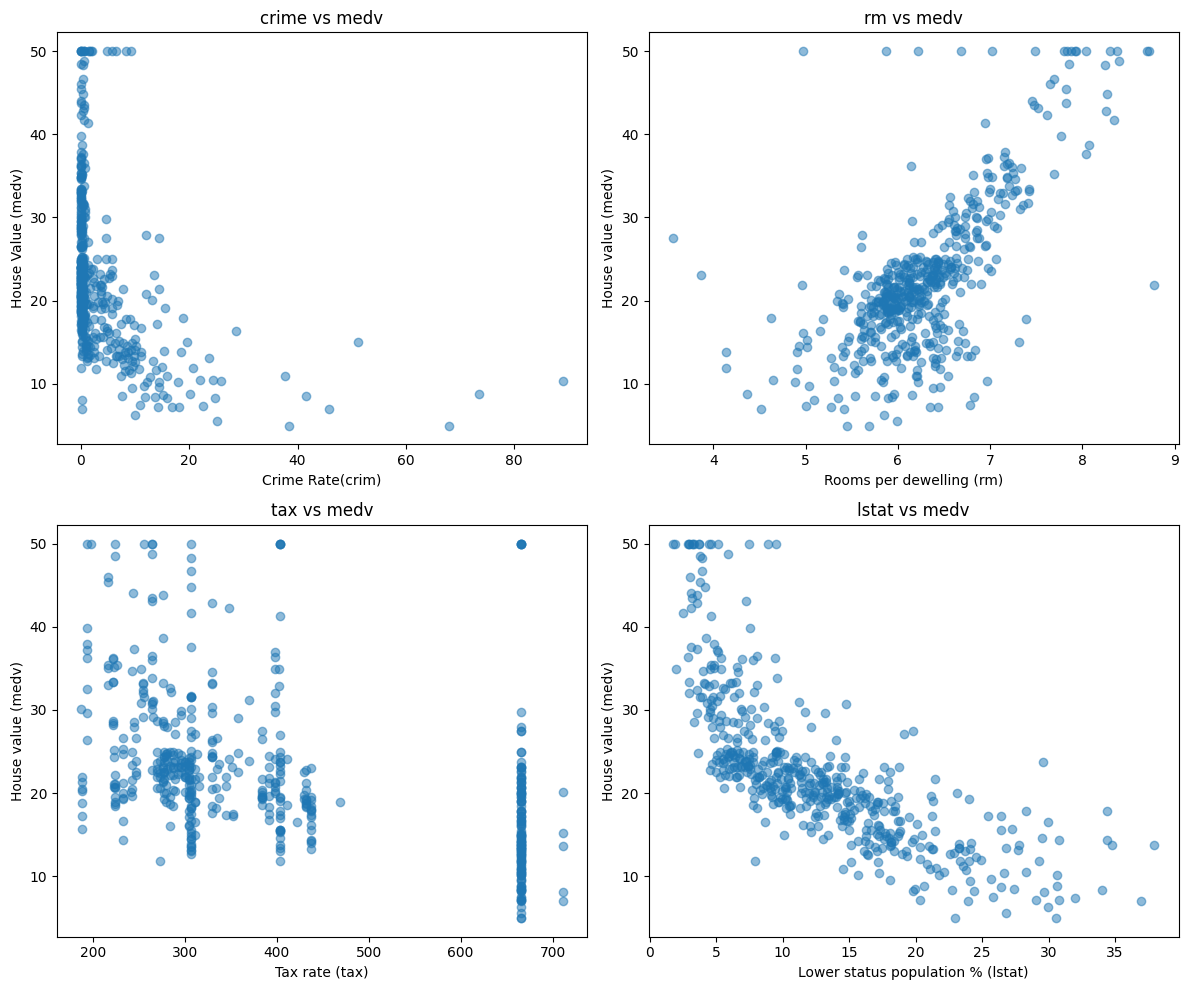

In [15]:
from scipy.stats import alpha
# check some features against medv
fig, axes = plt.subplots(2,2, figsize=(12,10))

#plot 1 - crim vs medv
axes[0,0].scatter(df['crim'], df['medv'], alpha=0.5)
axes[0,0].set_xlabel('Crime Rate(crim)')
axes[0,0].set_ylabel('House Value (medv)')
axes[0,0].set_title('crime vs medv')

#plot 2 - rm vs medv
axes[0,1].scatter(df['rm'], df['medv'], alpha=0.5)
axes[0,1].set_xlabel('Rooms per dewelling (rm)')
axes[0,1].set_ylabel('House value (medv)')
axes[0,1].set_title('rm vs medv')

#plot 3 - tax vs medv
axes[1,0].scatter(df['tax'], df['medv'], alpha=0.5)
axes[1,0].set_xlabel('Tax rate (tax)')
axes[1,0].set_ylabel('House value (medv)')
axes[1,0].set_title('tax vs medv')

#plot 4 - lstat vs medv
axes[1,1].scatter(df['lstat'], df['medv'], alpha=0.5)
axes[1,1].set_xlabel('Lower status population % (lstat)')
axes[1,1].set_ylabel('House value (medv)')
axes[1,1].set_title('lstat vs medv')

plt.savefig("Other_vs_medv.png", dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [28]:
from google.colab import files
files.download('Other_vs_medv.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

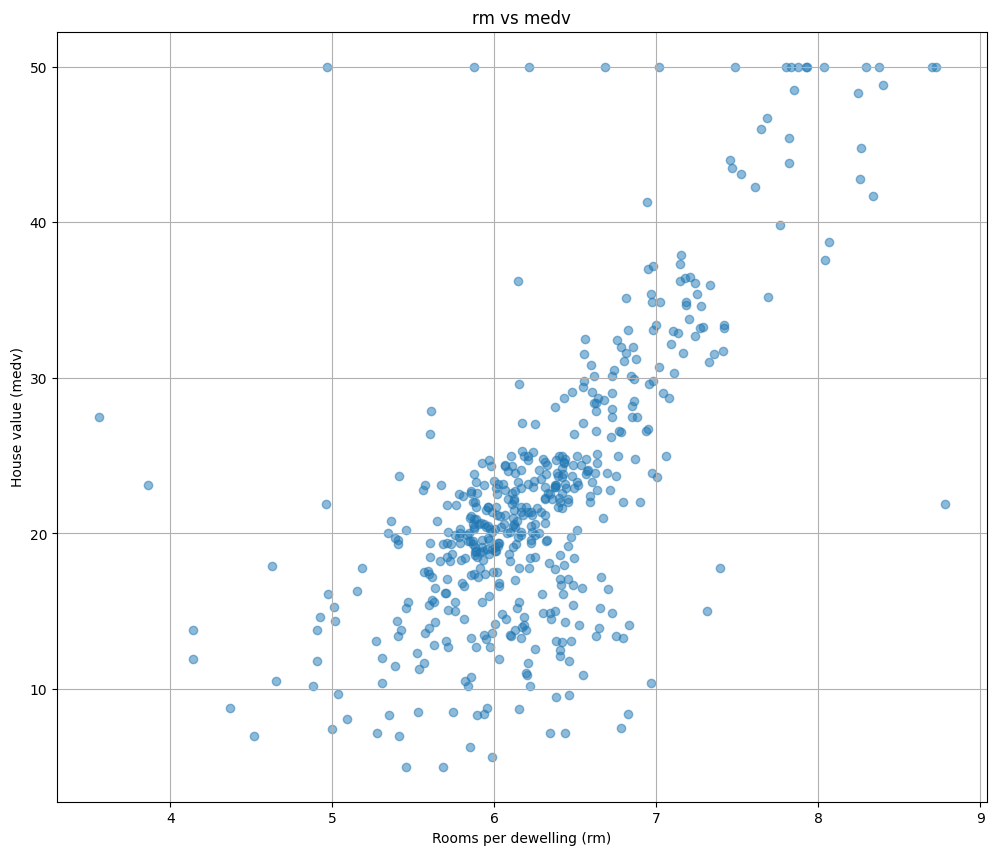

In [10]:
#Plot rm vs medv
fig, axes = plt.subplots( figsize=(12,10))
#plot 2 - rm vs medv
axes.scatter(df['rm'], df['medv'], alpha=0.5)
axes.set_xlabel('Rooms per dewelling (rm)')
axes.set_ylabel('House value (medv)')
axes.set_title('rm vs medv')
plt.grid()

#save the plot
plt.savefig('rm_vs_medv.png', dpi=150, bbox_inches='tight')

In [11]:
#download the plot
from google.colab import files
files.download('rm_vs_medv.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Create model object (empty to train)
model = LR()

#prepare data
x_rm = df[['rm']] # Double brackets to make DF 20 not series 10
y_medv = df['medv'] # only 10 series

# split into training and testing sets with feture that has strong relation
x_train, x_test, y_train, y_test = train_test_split(x_rm, y_medv, test_size=0.2, random_state=42)

# train using fit on training data
model.fit(x_train, y_train)

# Get the equation (LR) intercept_ (_ - beta0) coef_ (_ - beta1)
print(f'Equation: House vale = {model.intercept_:.2f} + {model.coef_[0]:.2f} * Rooms')
print(f'Each extra room adds: ${model.coef_[0] * 1000:.2f} to the hourse price.')
# Make prediction on the test data
y_pred = model.predict(x_test)

# Evaluate model using Mean suared error(MSE)
mse = mean_squared_error(y_test, y_pred)

#Evaluate RMSE - root mean suared error - the same unit as y
rmse = np.sqrt(mse)

#Evaluate with R-suared - proportion of variation  expalined
r2 = r2_score(y_test, y_pred)

print(f'Typical prediction is about: ${rmse * 1000:.0f}') # multiply by 1000
print(f'The room feature explain only: {r2:.3f} or {r2*100:.1f}% of price variation.')

Equation: House vale = -36.25 + 9.35 * Rooms
Each extra room adds: $9348.30 to the hourse price.
Typical prediction is about: $6793
The room feature explain only: 0.371 or 37.1% of price variation.


In [ ]:
#Compare with lstat or lower status population predictor
x_lstat = df[['lstat']] # double brackets dor 20 shape
y_medv = df['medv']

#split in train and test sets
x_train, x_test, y_train, y_test = train_test_split(x_lstat, y_medv, test_size=0.2, random_state=42)

#create model to be tarined
model_lstat = LR()
model_lstat.fit(x_train, y_train)

# Get the equation for LR
print(f'House value equation: {model_lstat.intercept_:.2f} + {model_lstat.coef_[0]:.2f} * lstat')

#Make prediction
y_pred = model_lstat.predict(x_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f'RMSE: ${rmse * 1000:.0f}')
print(f'R-squared: {r2:.3f}')

House value equation: 34.84 + -0.97 * lstat
RMSE: $5790
R-squared: 0.543


In [ ]:
#Multiple LR (with all features)
x_all = df.drop('medv', axis=1)
y_medv = df['medv']

#split data into train and test sets
x_train, x_test, y_train, y_test = train_test_split(x_all, y_medv, test_size=0.2, random_state=42)

# Create and train model
model_all = LR()
model_all.fit(x_train, y_train)

#Make prediction on test set
y_pred = model_all.predict(x_test)

# Evaluate model using metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Multiple LR Results:")
print(f'rm alone: R-squared = 0.371 (37.1%)')
print(f'lstat alone: R-squared = 0.543 (54.3%)')
print(f'All 13 features: R-squared = {r2:.3f} ({r2*100:.1f}%)')


Multiple LR Results:
rm alone: R-squared = 0.371 (37.1%)
lstat alone: R-squared = 0.543 (54.3%)
All 13 features: R-squared = 0.689 (68.9%)


In [ ]:
# Create the DF showing which predictor has what coefficient
coef_df = pd.DataFrame({
    'Predictor': x_all.columns,
    'Coefficient': model_all.coef_
})
print(coef_df)

   Predictor  Coefficient
0       crim    -0.127196
1         zn     0.030795
2      indus     0.025248
3       chas     3.049477
4        nox   -18.183246
5         rm     4.240098
6        age    -0.003594
7        dis    -1.465507
8        rad     0.239990
9        tax    -0.011275
10   ptratio    -0.894845
11     lstat    -0.537770


In [ ]:
#To get p-values, statsmodel (sm) required(for more detail output)
#add a constant column(intercept) to the predictors
x_train_with_const = sm.add_constant(x_train)

#Fit the model using statsmodels
model_sm = sm.OLS(y_train, x_train_with_const).fit()

#prints summary
print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                   medv   R-squared:                       0.740
Model:                            OLS   Adj. R-squared:                  0.732
Method:                 Least Squares   F-statistic:                     92.64
Date:                Tue, 07 Apr 2026   Prob (F-statistic):          2.82e-106
Time:                        05:50:13   Log-Likelihood:                -1203.1
No. Observations:                 404   AIC:                             2432.
Df Residuals:                     391   BIC:                             2484.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         36.9705      5.555      6.655      0.0

In [ ]:
# The p-value of statsmodel summarry
p_values = model_sm.pvalues
p_df = pd.DataFrame({
    'Predictor': p_values.index,
    'p-value': p_values.values,
    'Significan (p<0.05)': p_values.values < 0.05
})
print(p_df)

   Predictor       p-value  Significan (p<0.05)
0      const  9.584357e-11                 True
1       crim  3.594528e-04                 True
2         zn  6.000263e-02                False
3      indus  7.132770e-01                False
4       chas  1.859913e-03                 True
5        nox  3.146232e-05                 True
6         rm  9.882957e-18                 True
7        age  8.089312e-01                False
8        dis  5.788350e-10                 True
9        rad  2.061040e-03                 True
10       tax  9.561203e-03                 True
11   ptratio  2.671782e-09                 True
12     lstat  1.599233e-19                 True


In [ ]:
# Let's remove those features p-value (indus and age)
keep_predictors = ['crim', 'zn', 'chas', 'nox', 'rm', 'dis', 'rad', 'tax', 'ptratio', 'lstat']
x_reduced = df[keep_predictors]
y_medv = df['medv']

#split into train and test sets
x_train_r, x_test_r, y_train_r, y_test_r = train_test_split(x_reduced, y_medv, test_size=0.2, random_state=42)

#Train the model
model_reduced = LR()
model_reduced.fit(x_train_r, y_train_r)

#predict and evaluate
y_pred_r = model_reduced.predict(x_test_r)

# Percentage of variation in Y explained by X's. Higher is better.
r2_reduced = r2_score(y_test_r, y_pred_r)

# Typical prediction error in same units as Y. Lower is better.
rmse_reduced = np.sqrt(mean_squared_error(y_test_r, y_pred_r))

print(f'Full model: R-squared = 0.689, RMSE=${rmse*1000:.0f}')
print(f'Reduced Model: R-squared = {r2_reduced:.3f}, RMSE=${rmse_reduced * 1000:.0f}')
print(f"Difference in r-squared: {0.689 - r2_reduced:.4f}")


Full model: R-squared = 0.689, RMSE=$4773
Reduced Model: R-squared = 0.691, RMSE=$4762
Difference in r-squared: -0.0018


#Removing#  *indus* and *age* IMPROVED the model slightly.

The *R-squared* went UP from #0.689# to #0.691#.
The *RMSE* went DOWN from #$4,773# to #$4,762#.

This confirms what the p-values told us: indus and age were not just useless. They were adding noise that hurt the model's ability to predict on new data.

#Check for Collinearity#
Even with a good model, we may have redundant predictors. Collinearity means two or more predictors are highly correlated. This makes coefficients unstable and hard to interpret.
#VIF (*Variance Inflation Factor*):# A number that tells you how much a predictor is redundant because it is correlated with other predictors.
*VIF* = 1 means no redundancy. VIF > 5 or 10 means the predictor is too similar to others and should be considered for removal.

In [ ]:
# Import models
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calculate VIF for each predictor in the reduced model
reduced_predictors = ['crim', 'zn', 'chas', 'nox', 'rm', 'dis', 'rad', 'tax', 'ptratio', 'lstat']
x_reduced = df[reduced_predictors]

#add constant column (required for VIF calculation)
x_with_const = sm.add_constant(x_reduced)

#Calculate VIF for each predictors with out constant column
vif_data = pd.DataFrame()
vif_data['predictor'] = x_reduced.columns
vif_data['VIF'] = [variance_inflation_factor(x_with_const.values, i+1) for i in range(len(x_reduced.columns))]
print(vif_data)

high_vif = vif_data[vif_data['VIF'] > 5]
print('\n', high_vif)

  predictor       VIF
0      crim  1.765478
1        zn  2.239107
2      chas  1.056997
3       nox  3.758338
4        rm  1.819577
5       dis  3.438955
6       rad  6.826385
7       tax  7.258419
8   ptratio  1.755565
9     lstat  2.527415

   predictor       VIF
6       rad  6.826385
7       tax  7.258419
